# 전이학습 기반 컴퓨터 비전 분류: Ants vs Bees

다루는 학습 순서는 다음 구조임.

1. 실험 환경, 재현성, 장치 설정
2. Hymenoptera ants/bees 데이터셋 다운로드와 `ImageFolder` 구조 확인
3. 데이터 전처리, augmentation, `Dataset`과 `DataLoader` 구성
4. ResNet-18 기반 모델 구성과 forward pass shape 점검
5. 손실 함수, optimizer, scheduler, 학습·평가 함수 구성
6. 사전학습 ConvNet 전체 fine-tuning
7. 고정 feature extractor 방식의 전이학습
8. metric 기록, 시각화, TensorBoard 로그 생성
9. `state_dict` 기반 저장·복원과 단일 이미지 추론
10. 구성 요약, 학습 목표, 확장 실험 방향

## 1. 문제 설정과 전이학습 구조

분류 문제의 입력은 RGB 이미지 mini-batch $x \in \mathbb{R}^{B \times 3 \times H \times W}$임. 여기서 $B$는 batch size, $3$은 RGB channel 수, $H$와 $W$는 이미지 높이와 너비임. 본 실험에서는 ResNet 계열 사전학습 모델의 표준 입력 크기에 맞추어 $H=W=224$로 변환함.

출력은 두 개 class에 대한 logit $o \in \mathbb{R}^{B \times 2}$임. 첫 번째 축은 batch dimension, 두 번째 축은 class dimension임. 각 행 $o_i$는 $i$번째 이미지에 대한 class별 비정규화 점수이며, 학습 손실은 softmax와 negative log-likelihood를 결합한 cross entropy로 정의됨.

$$
\mathcal{L}
= -\frac{1}{B}\sum_{i=1}^{B}
\log
\frac{\exp(o_{i,y_i})}
{\sum_{c=1}^{C}\exp(o_{i,c})}
$$

전이학습의 기본 구성은 다음과 같음.

$$
z = f_{\theta_{\mathrm{base}}}(x), \qquad o = Wz + b
$$

$f_{\theta_{\mathrm{base}}}$는 ImageNet 등 대규모 데이터로 학습된 CNN feature extractor이며, $W,b$는 ants/bees 이진 분류를 위해 새로 구성한 linear classifier임. fine-tuning 방식은 $\theta_{\mathrm{base}}, W, b$를 함께 갱신하는 방식임. fixed feature extractor 방식은 $\theta_{\mathrm{base}}$를 고정하고 $W,b$만 학습하는 방식임.

## 2. 원본 튜토리얼의 시각적 출력 예시

아래 이미지는 PyTorch 공식 튜토리얼에 포함된 학습 이미지 시각화 결과임. 본 강의에서도 동일한 위치의 데이터 확인 절차를 수행함.

![PyTorch transfer learning tutorial sample grid](https://docs.pytorch.org/tutorials/_images/sphx_glr_transfer_learning_tutorial_001.png)

그림 1. 데이터 augmentation 후 mini-batch 시각화 예시. 출처: PyTorch Tutorials, Transfer Learning for Computer Vision Tutorial.

## 3. 실행 환경, 난수 고정, 장치 설정

딥러닝 실험은 난수 초기화, 데이터 shuffle, GPU 연산 방식에 따라 결과가 달라질 수 있음. 따라서 seed를 고정하고, 가능한 범위에서 결정적 연산 설정을 적용함. 다만 모든 GPU kernel이 완전히 동일한 결과를 보장하는 것은 아니므로, 재현성 설정은 오차 범위를 줄이는 절차로 이해하는 것이 적절함.

PyTorch의 `Tensor`는 단일 dtype을 갖는 다차원 배열 객체임. `Tensor`는 CPU 또는 GPU 같은 특정 device에 위치할 수 있으며, `requires_grad=True`인 floating-point tensor는 autograd 그래프에 연산 이력을 남김. 신경망의 학습 가능한 값은 일반적으로 `torch.nn.Parameter`로 등록된 tensor이며, `nn.Module`은 parameter와 하위 module을 계층적으로 관리하는 기본 단위임.

Colab에서는 기본 작업 디렉터리가 일반적으로 `/content`임. 본 강의에서는 Colab 런타임을 감지하면 `/content` 아래에 `data`, `checkpoints`, `runs` 디렉터리를 생성하고, 일반 Jupyter 환경에서는 현재 작업 디렉터리를 사용함. GPU 런타임이 아닌 경우에도 실행은 가능하지만, 두 개의 $25$ epoch 학습 실험은 CPU에서 상당히 오래 걸릴 수 있음.

In [ ]:
from __future__ import annotations

import os
import platform
import random
import sys
import time
import urllib.request
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.utils import make_grid

try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_AVAILABLE = True
except Exception as tensorboard_import_error:
    SummaryWriter = None
    TENSORBOARD_AVAILABLE = False


def set_seed(seed: int = 42) -> None: # 시드값 고정
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def get_default_device() -> torch.device: # accelerator 설정 (사용 가능한게 없으면 CPU)
    if hasattr(torch, "accelerator"):
        try:
            if torch.accelerator.is_available():
                accelerator = torch.accelerator.current_accelerator()
                accelerator_name = accelerator.type if hasattr(accelerator, "type") else str(accelerator)
                return torch.device(accelerator_name)
        except Exception:
            pass
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def check_runtime_prerequisites() -> None:
    checks = {
        "torch import": torch.__version__ is not None,
        "torchvision import": torchvision.__version__ is not None,
        "ResNet18 weights enum": hasattr(models, "ResNet18_Weights"),
        "ImageFolder": hasattr(datasets, "ImageFolder"),
        "Normalize transform": hasattr(transforms, "Normalize"),
    }
    failed = [name for name, ok in checks.items() if not ok]
    if failed:
        raise RuntimeError(f"Runtime prerequisite check failed: {failed}")

    dummy_model = models.resnet18(weights=None)
    dummy_model.fc = nn.Linear(dummy_model.fc.in_features, 2)
    dummy_model.eval()
    dummy_inputs = torch.randn(2, 3, 224, 224)
    with torch.no_grad():
        dummy_logits = dummy_model(dummy_inputs)
    assert tuple(dummy_logits.shape) == (2, 2), tuple(dummy_logits.shape)
    del dummy_model, dummy_inputs, dummy_logits


SEED = 42
set_seed(SEED)

IN_COLAB = "google.colab" in sys.modules
device = get_default_device()
PROJECT_DIR = Path("/content") if IN_COLAB else Path.cwd()
DATA_ROOT = PROJECT_DIR / "data"
DATA_DIR = DATA_ROOT / "hymenoptera_data"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
RUNS_DIR = PROJECT_DIR / "runs" / "transfer_learning_lecture"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

check_runtime_prerequisites()

print(f"Python version: {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")
print(f"Colab runtime: {IN_COLAB}")
print(f"Device: {device}")
print(f"TensorBoard available: {TENSORBOARD_AVAILABLE}")
print(f"Project directory: {PROJECT_DIR}")

if device.type == "cpu":
    print("GPU runtime is not enabled. The notebook remains executable, but training will be slower on CPU.")

Python version: 3.12.13
PyTorch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu
Colab runtime: True
Device: cpu
TensorBoard available: True
Project directory: /content
GPU runtime is not enabled. The notebook remains executable, but training will be slower on CPU.


## 4. 데이터셋 다운로드와 디렉터리 구조

원본 튜토리얼은 `hymenoptera_data`를 사용함. 데이터는 ants와 bees 두 class로 구성되며, `train`과 `val` split이 별도 디렉터리로 제공됨. `torchvision.datasets.ImageFolder`는 아래와 같이 class별 하위 폴더를 label로 해석함.

```text
hymenoptera_data/
  train/
    ants/
    bees/
  val/
    ants/
    bees/
```

`ImageFolder`에서 label index는 class 폴더 이름을 정렬한 순서로 결정됨. 이 실험에서는 일반적으로 `ants`가 $0$, `bees`가 $1$인 구조가 됨. 데이터셋이 작기 때문에, 사전학습 feature를 활용하는 전이학습 설정이 적절한 비교 대상임.

In [ ]:
DATA_URL = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
ZIP_PATH = DATA_ROOT / "hymenoptera_data.zip"

# 데이터 다운 후 압축 해제
def download_and_extract_hymenoptera(
    url: str = DATA_URL,
    data_root: Path = DATA_ROOT,
    data_dir: Path = DATA_DIR,
    zip_path: Path = ZIP_PATH,
) -> Path:
    data_root.mkdir(parents=True, exist_ok=True)
    if data_dir.exists():
        print(f"Dataset already exists: {data_dir}")
        return data_dir

    print(f"Downloading dataset from {url}")
    urllib.request.urlretrieve(url, zip_path)

    print(f"Extracting dataset to {data_root}")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_root)

    if not data_dir.exists():
        raise FileNotFoundError(f"Expected dataset directory not found: {data_dir}")
    return data_dir


data_dir = download_and_extract_hymenoptera()

for split in ["train", "val"]:
    split_dir = data_dir / split
    print(f"\n[{split}]")
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            num_images = sum(1 for path in class_dir.iterdir() if path.is_file())
            print(f"  {class_dir.name:>5}: {num_images:3d} images")
            # 각 클래스별 이미지 개수 확인

Dataset already exists: /content/data/hymenoptera_data

[train]
   ants: 124 images
   bees: 121 images

[val]
   ants:  70 images
   bees:  83 images


## 5. 전처리와 augmentation

CNN 입력 tensor는 일반적으로 $B \times C \times H \times W$ 순서를 따름. 원본 이미지는 PIL image 또는 파일 형태로 저장되어 있으며, `transforms` pipeline을 통해 다음 단계로 변환됨.

1. 학습 split: `RandomResizedCrop(224)`와 `RandomHorizontalFlip()`을 사용하여 spatial augmentation 수행함
2. 검증 split: `Resize(256)` 후 `CenterCrop(224)`를 적용하여 결정적 평가 입력 구성함
3. 모든 split: `ToTensor()`로 $C \times H \times W$ tensor로 변환하고, ImageNet 평균과 표준편차로 channel-wise 정규화함

정규화는 channel $c$에 대해 다음 연산임.

$$
\hat{x}_{c,h,w} = \frac{x_{c,h,w} - \mu_c}{\sigma_c}
$$

사전학습된 ResNet-18은 ImageNet 입력 통계에 맞추어 학습되었으므로, 동일한 평균과 표준편차를 사용하는 것이 중요함. 이 값은 `torchvision` pretrained weights의 transform 설명과 일치하는 표준 설정임.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

BATCH_SIZE = 4
NUM_WORKERS = 2 if os.name != "nt" else 0
PIN_MEMORY = device.type == "cuda"


data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224), # 무작위로 잘라내서 224*224 크기로 맞춤
        transforms.RandomHorizontalFlip(), # 50% 좌우반전
        transforms.ToTensor(), # 0~225 -> 0.0~1.0
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD), # 앞서 정의한 표준 규격으로 정규화
    ]),
    "val": transforms.Compose([
        transforms.Resize(256), # 전체 이미지를 256 크기로 줄임
        transforms.CenterCrop(224), # 정중앙을 기준으로 224*224로 잘라냄
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}
# 데이터셋 생성
image_datasets = {
    split: datasets.ImageFolder(str(data_dir / split), data_transforms[split])
    for split in ["train", "val"]
}
# 데이터로더 구축 및 최적화
dataloaders = {
    split: DataLoader(
        image_datasets[split],
        batch_size=BATCH_SIZE, # 한 번에 4장씩
        shuffle=(split == "train"), # 훈련데이터는 섞음
        num_workers=NUM_WORKERS, # 데이터 로딩에 쓸 일꾼(코어) 수
        pin_memory=PIN_MEMORY, # GPU학습을 더 빠르게 하기 위해 메모리에 고정
    )
    for split in ["train", "val"]
}

dataset_sizes = {split: len(image_datasets[split]) for split in ["train", "val"]}
class_names = image_datasets["train"].classes
num_classes = len(class_names)

print(f"Class names: {class_names}")
print(f"Class-to-index mapping: {image_datasets['train'].class_to_idx}")
print(f"Dataset sizes: {dataset_sizes}")
print(f"Batch size: {BATCH_SIZE}")

Class names: ['ants', 'bees']
Class-to-index mapping: {'ants': 0, 'bees': 1}
Dataset sizes: {'train': 244, 'val': 153}
Batch size: 4


## 6. `Dataset`과 `DataLoader`의 출력 형태 확인

`Dataset`은 index 하나에 대해 `(image, label)` 쌍을 반환하는 객체임. `DataLoader`는 여러 sample을 모아 mini-batch를 생성하고, 필요 시 shuffle과 병렬 loading을 수행하는 iterable임.

현재 설정에서 `DataLoader`의 한 batch는 다음 구조임.

- `inputs`: `torch.float32` tensor, shape $[B, 3, 224, 224]$
- `labels`: `torch.int64` tensor, shape $[B]$
- `labels[i]`: $i$번째 이미지의 class index

정규화 이후 `inputs`의 값 범위는 $[0, 1]$이 아니며, channel 평균을 빼고 표준편차로 나눈 값이므로 음수와 $1$보다 큰 값이 나타날 수 있음.

In [ ]:
inputs, labels = next(iter(dataloaders["train"]))

 # 모델의 입력으로 들어갈 이미지들의 정보
print(f"inputs.shape: {tuple(inputs.shape)}")
print(f"inputs.dtype: {inputs.dtype}")
# 정답 레이블 정보
print(f"labels.shape: {tuple(labels.shape)}")
print(f"labels.dtype: {labels.dtype}")
print(f"label indices: {labels.tolist()}")
# 읽을 수 있게 변환한 정답
print(f"label names: {[class_names[index] for index in labels.tolist()]}")
# 정규화된 픽셀 값의 범위
print(f"normalized input range: min={inputs.min().item():.3f}, max={inputs.max().item():.3f}")

inputs.shape: (4, 3, 224, 224)
inputs.dtype: torch.float32
labels.shape: (4,)
labels.dtype: torch.int64
label indices: [1, 1, 0, 0]
label names: ['bees', 'bees', 'ants', 'ants']
normalized input range: min=-2.118, max=2.640


## 7. 정규화 역변환과 mini-batch 시각화

학습 입력을 화면에 표시하려면 ImageNet 정규화의 역연산을 적용해야 함. 정규화된 tensor $\hat{x}$에 대해 원래 scale의 tensor는 다음과 같이 복원됨.

$$
x_{c,h,w} = \hat{x}_{c,h,w}\sigma_c + \mu_c
$$

`torchvision.utils.make_grid`는 $B \times C \times H \times W$ mini-batch를 하나의 grid image로 결합함. 시각화는 augmentation이 실제로 이미지의 crop, 좌우 반전, scale 변화를 생성하는지 확인하는 절차임.

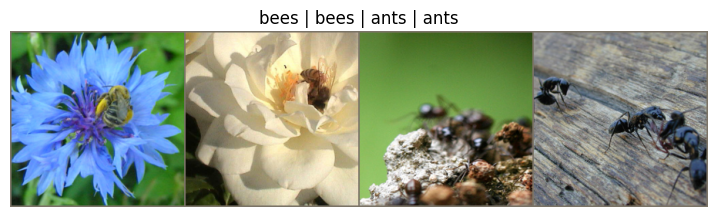

In [ ]:
# 역정규화 함수: 숫자를 이미지 픽셀 값 범위로 복원
def denormalize(tensor: torch.Tensor, mean: List[float] = IMAGENET_MEAN, std: List[float] = IMAGENET_STD) -> torch.Tensor:
    mean_tensor = torch.tensor(mean, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    std_tensor = torch.tensor(std, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    return tensor * std_tensor + mean_tensor
    # (정규화된 이미지 * 표준편차) / 평균


# 텐서 이미지 출력
def imshow_tensor(image_tensor: torch.Tensor, title: str | List[str] | None = None) -> None:
    image_tensor = denormalize(image_tensor.detach().cpu()).clamp(0, 1)
    np_image = image_tensor.numpy().transpose((1, 2, 0)) # PyTorch와 Numpy는 이미지를 다루는 순서가 달라서 재배치해줌
    plt.figure(figsize=(9, 5))
    plt.imshow(np_image)
    if title is not None:
        if isinstance(title, list):
            title = " | ".join(title)
        plt.title(title)
    plt.axis("off")
    plt.show()


batch_grid = make_grid(inputs, nrow=BATCH_SIZE)
imshow_tensor(batch_grid, title=[class_names[index] for index in labels.tolist()])

## 8. ResNet-18 기반 classifier 구성

ResNet-18은 residual block을 사용하는 CNN 구조임. residual block의 핵심 계산은 다음 형태로 표현됨.

$$
y = \mathcal{F}(x;\theta) + x
$$

여기서 $\mathcal{F}$는 convolution, normalization, activation으로 구성된 residual branch이며, $x$는 identity 또는 projection shortcut임. 이러한 구조는 깊은 network에서 gradient 전달과 최적화 안정성을 개선하기 위해 도입된 구조임.

`torchvision.models.resnet18(weights=...)`는 사전학습된 weight를 불러올 수 있음. 최신 `torchvision` API에서는 기존 `pretrained=True` 대신 weights enum을 지정하는 방식이 권장됨. ImageNet-1K 사전학습 weights를 사용하는 경우, 마지막 fully connected layer는 원래 $1000$개 class에 대한 `Linear(512, 1000)` 구조임. 본 문제는 ants/bees $2$-class 분류이므로 마지막 layer를 `Linear(512, 2)`로 교체함.

forward pass의 주요 shape 흐름은 다음 구조임.

- input image batch: $[B, 3, 224, 224]$
- convolutional backbone: $[B, 512, 7, 7]$
- adaptive average pool: $[B, 512, 1, 1]$
- flattened feature: $[B, 512]$
- new classifier logits: $[B, 2]$

In [ ]:
# 파라미터 개수 계산, 요약
def count_parameters(model: nn.Module) -> Dict[str, int]:
    total = sum(param.numel() for param in model.parameters())
    trainable = sum(param.numel() for param in model.parameters() if param.requires_grad)
    frozen = total - trainable
    return {"total": total, "trainable": trainable, "frozen": frozen}

def summarize_parameters(model: nn.Module, max_rows: int = 20) -> None:
    rows = []
    for name, param in model.named_parameters():
        rows.append((name, tuple(param.shape), param.numel(), param.requires_grad))

    counts = count_parameters(model)
    print(f"Total parameters    : {counts['total']:,}")
    print(f"Trainable parameters: {counts['trainable']:,}")
    print(f"Frozen parameters   : {counts['frozen']:,}")
    print("\nParameter tensors")
    print(f"{'name':45s} {'shape':22s} {'numel':>12s} {'trainable':>10s}")
    print("-" * 95)
    for name, shape, numel, trainable in rows[:max_rows]:
        print(f"{name:45s} {str(shape):22s} {numel:12,d} {str(trainable):>10s}")
    if len(rows) > max_rows:
        print(f"... {len(rows) - max_rows} more parameter tensors")


# RasNet18
def build_resnet18_classifier(num_classes: int, fine_tune: bool = True) -> Tuple[nn.Module, models.ResNet18_Weights]:
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    # 사전학습된 RasNet18 모델을 가져옴

    if not fine_tune:
        for param in model.parameters():
            param.requires_grad = False
        # 기존 모델이 가진 지식을 어떻게 처리할껀지 조건문으로 설정

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model, weights
    # 기존 LasNet은 여러 사물을 맞추게 설계되어 있지만 우리는 개미와 벌만 맞추면 되기에 해당 부분만 떼어냄
    # 2개짜리 출력을 내보내는 새로운 선형 레이어로 바꿈

model_shape, resnet18_weights = build_resnet18_classifier(num_classes=num_classes, fine_tune=True)
print(resnet18_weights)
print(f"New classifier: {model_shape.fc}")
summarize_parameters(model_shape, max_rows=12)

ResNet18_Weights.IMAGENET1K_V1
New classifier: Linear(in_features=512, out_features=2, bias=True)
Total parameters    : 11,177,538
Trainable parameters: 11,177,538
Frozen parameters   : 0

Parameter tensors
name                                          shape                         numel  trainable
-----------------------------------------------------------------------------------------------
conv1.weight                                  (64, 3, 7, 7)                 9,408       True
bn1.weight                                    (64,)                            64       True
bn1.bias                                      (64,)                            64       True
layer1.0.conv1.weight                         (64, 64, 3, 3)               36,864       True
layer1.0.bn1.weight                           (64,)                            64       True
layer1.0.bn1.bias                             (64,)                            64       True
layer1.0.conv2.weight                         

## 9. Forward pass shape 점검

모델이 의도한 형태로 계산되는지 확인하기 위해 주요 module에 forward hook을 등록함. hook은 실제 계산 결과를 변경하지 않고, 각 layer의 입력·출력 shape를 기록함. 이 절차는 classifier 교체 이후 class dimension이 $[B, 2]$인지 확인하는 검증 단계임.

`nn.Module`의 `train()`과 `eval()`은 BatchNorm, Dropout 등 mode-dependent module의 동작을 바꾸는 메서드임. shape 확인은 parameter 갱신이 필요하지 않으므로 `torch.no_grad()` 범위에서 수행함.

In [ ]:
# 중간점검을 할 수 있는 Hook 생성
def collect_forward_shapes(
    model: nn.Module,
    sample_batch: torch.Tensor,
    target_modules: Iterable[str] | None = None,
) -> Tuple[List[Dict[str, object]], torch.Tensor]:
    if target_modules is None:
        target_modules = ["conv1", "bn1", "relu", "maxpool", "layer1", "layer2", "layer3", "layer4", "avgpool", "fc"]

    records: List[Dict[str, object]] = []
    handles = []
    modules = dict(model.named_modules())

    def make_hook(name: str):
        def hook(module: nn.Module, module_input: Tuple[torch.Tensor, ...], module_output: torch.Tensor) -> None:
            input_shape = tuple(module_input[0].shape) if module_input else None
            if isinstance(module_output, torch.Tensor):
                output_shape = tuple(module_output.shape)
            elif isinstance(module_output, (list, tuple)) and len(module_output) > 0 and isinstance(module_output[0], torch.Tensor):
                output_shape = tuple(module_output[0].shape)
            else:
                output_shape = type(module_output).__name__
            records.append({"module": name, "input": input_shape, "output": output_shape})
        return hook

    for name in target_modules:
        if name not in modules:
            raise KeyError(f"Module not found: {name}")
        handles.append(modules[name].register_forward_hook(make_hook(name)))

    model = model.to(device)
    model.eval() # 평가모드
    with torch.no_grad():# 가중치가 업데이트 안되게
        logits = model(sample_batch.to(device, non_blocking=PIN_MEMORY))

    for handle in handles:
        handle.remove() # 다 썻으면 제거

    return records, logits


shape_records, sample_logits = collect_forward_shapes(model_shape, inputs)
print(f"Final logits shape: {tuple(sample_logits.shape)}")
print(f"Final logits dtype : {sample_logits.dtype}")
print("\nForward shape table")
print(f"{'module':10s} {'input':24s} {'output':24s}")
print("-" * 62)
for record in shape_records:
    print(f"{record['module']:10s} {str(record['input']):24s} {str(record['output']):24s}")

del model_shape # 메모리 정
if device.type == "cuda":
    torch.cuda.empty_cache()

Final logits shape: (4, 2)
Final logits dtype : torch.float32

Forward shape table
module     input                    output                  
--------------------------------------------------------------
conv1      (4, 3, 224, 224)         (4, 64, 112, 112)       
bn1        (4, 64, 112, 112)        (4, 64, 112, 112)       
relu       (4, 64, 112, 112)        (4, 64, 112, 112)       
maxpool    (4, 64, 112, 112)        (4, 64, 56, 56)         
layer1     (4, 64, 56, 56)          (4, 64, 56, 56)         
layer2     (4, 64, 56, 56)          (4, 128, 28, 28)        
layer3     (4, 128, 28, 28)         (4, 256, 14, 14)        
layer4     (4, 256, 14, 14)         (4, 512, 7, 7)          
avgpool    (4, 512, 7, 7)           (4, 512, 1, 1)          
fc         (4, 512)                 (4, 2)                  


## 10. 손실 함수, optimizer, scheduler, autograd

`nn.CrossEntropyLoss`는 class별 logit과 정수 class index target을 입력으로 받는 다중 class 분류 손실임. 입력 `outputs`의 shape는 $[B, C]$, target `labels`의 shape는 $[B]$임. target은 one-hot vector가 아니라 `torch.long` dtype의 class index여야 함.

학습 단계의 계산 흐름은 다음 순서임.

1. `model.train()`으로 학습 mode 설정함
2. `optimizer.zero_grad(set_to_none=True)`로 이전 gradient 제거함
3. `outputs = model(inputs)`로 forward pass 수행함
4. `loss = criterion(outputs, labels)`로 scalar 손실 계산함
5. `loss.backward()`로 autograd가 parameter gradient 계산함
6. `optimizer.step()`으로 parameter 갱신함
7. epoch 단위로 scheduler가 learning rate를 조정함

평가 단계에서는 `model.eval()`과 `torch.no_grad()`를 함께 사용함. `eval()`은 module의 동작 mode를 바꾸는 설정이고, `no_grad()`는 autograd graph 생성을 막는 설정이므로 의미가 다름.

In [ ]:
@dataclass
class PhaseMetrics:
    loss: float
    acc: float


def get_current_lr(optimizer: optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def safe_load_state_dict(path: Path, map_location: torch.device | str) -> Dict[str, torch.Tensor]:
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)

# 한 에폭을 돌리기 위한 함수
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
) -> PhaseMetrics:
    model.train() # 훈련
    running_loss = 0.0
    running_corrects = 0
    num_samples = len(dataloader.dataset)

    for inputs_batch, labels_batch in dataloader:
        inputs_batch = inputs_batch.to(device, non_blocking=PIN_MEMORY)
        labels_batch = labels_batch.to(device, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True) # 지난 배치의 잔여 기울기 초기화
        outputs = model(inputs_batch) # 순방향 연산
        loss = criterion(outputs, labels_batch) # 손실 계산
        loss.backward() # 역전파 연산
        optimizer.step() # 가중치 업데이트

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * inputs_batch.size(0)
        running_corrects += (preds == labels_batch).sum().item()

    epoch_loss = running_loss / num_samples
    epoch_acc = running_corrects / num_samples
    return PhaseMetrics(loss=epoch_loss, acc=epoch_acc)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> PhaseMetrics:
    model.eval() # 평가를 하기 때문에 가중치 관련 함수 없음
    running_loss = 0.0
    running_corrects = 0
    num_samples = len(dataloader.dataset)

    for inputs_batch, labels_batch in dataloader:
        inputs_batch = inputs_batch.to(device, non_blocking=PIN_MEMORY)
        labels_batch = labels_batch.to(device, non_blocking=PIN_MEMORY)

        outputs = model(inputs_batch)
        loss = criterion(outputs, labels_batch)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * inputs_batch.size(0)
        running_corrects += (preds == labels_batch).sum().item()

    epoch_loss = running_loss / num_samples
    epoch_acc = running_corrects / num_samples
    return PhaseMetrics(loss=epoch_loss, acc=epoch_acc)


# 전체 학습 총괄
def fit_model(
    model: nn.Module,
    dataloaders: Dict[str, DataLoader],
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: lr_scheduler.LRScheduler,
    device: torch.device,
    num_epochs: int,
    checkpoint_path: Path,
    run_name: str,
) -> Tuple[nn.Module, List[Dict[str, float]]]:
    since = time.time()
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    model = model.to(device)

    writer = None
    if TENSORBOARD_AVAILABLE:
        writer = SummaryWriter(log_dir=str(RUNS_DIR / run_name))

    best_acc = -1.0
    torch.save(model.state_dict(), checkpoint_path)
    history: List[Dict[str, float]] = []

    for epoch in range(1, num_epochs + 1):
        lr_before_step = get_current_lr(optimizer)
        train_metrics = train_one_epoch(model, dataloaders["train"], criterion, optimizer, device)
        val_metrics = evaluate(model, dataloaders["val"], criterion, device)

        if val_metrics.acc > best_acc: # 최고 성능을 내면 모델 저장
            best_acc = val_metrics.acc
            torch.save(model.state_dict(), checkpoint_path)

        row = {
            "epoch": float(epoch),
            "lr": lr_before_step,
            "train_loss": train_metrics.loss,
            "train_acc": train_metrics.acc,
            "val_loss": val_metrics.loss,
            "val_acc": val_metrics.acc,
        }
        history.append(row)

        if writer is not None:
            writer.add_scalars("loss", {"train": train_metrics.loss, "val": val_metrics.loss}, epoch)
            writer.add_scalars("accuracy", {"train": train_metrics.acc, "val": val_metrics.acc}, epoch)
            writer.add_scalar("learning_rate", lr_before_step, epoch)

        print(
            f"Epoch {epoch:02d}/{num_epochs:02d} | "
            f"lr={lr_before_step:.6f} | "
            f"train loss={train_metrics.loss:.4f}, acc={train_metrics.acc:.4f} | "
            f"val loss={val_metrics.loss:.4f}, acc={val_metrics.acc:.4f}"
        )

        scheduler.step()

    if writer is not None:
        writer.close()

    elapsed = time.time() - since
    print(f"Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    print(f"Best validation accuracy: {best_acc:.4f}")

    best_state_dict = safe_load_state_dict(checkpoint_path, map_location=device)
    model.load_state_dict(best_state_dict)
    return model, history

## 11. Metric 기록과 시각화 함수

학습 과정의 손실과 정확도를 epoch 단위로 기록함. train loss는 parameter 갱신에 직접 사용되는 objective의 평균값이며, validation loss와 accuracy는 현재 모델의 일반화 상태를 확인하기 위한 지표임.

작은 데이터셋에서는 validation accuracy가 epoch마다 크게 변동할 수 있음. 따라서 best validation accuracy를 기준으로 checkpoint를 저장하고, 마지막 epoch 모델이 아니라 검증 성능이 가장 높았던 모델을 복원하는 방식이 적절함.

In [ ]:
def plot_history(history: List[Dict[str, float]], title: str) -> None:
    epochs = [int(item["epoch"]) for item in history]

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, [item["train_loss"] for item in history], marker="o", label="train")
    plt.plot(epochs, [item["val_loss"] for item in history], marker="o", label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title}: loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, [item["train_acc"] for item in history], marker="o", label="train")
    plt.plot(epochs, [item["val_acc"] for item in history], marker="o", label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title}: accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def summarize_history(history: List[Dict[str, float]], name: str) -> Dict[str, float | str]:
    best_epoch = max(history, key=lambda item: item["val_acc"])
    final_epoch = history[-1]
    return {
        "name": name,
        "best_epoch": best_epoch["epoch"],
        "best_val_acc": best_epoch["val_acc"],
        "final_train_acc": final_epoch["train_acc"],
        "final_val_acc": final_epoch["val_acc"],
    }

## 12. TensorBoard 로그 구성

`SummaryWriter`가 사용 가능한 환경에서는 `fit_model()` 함수가 epoch별 loss, accuracy, learning rate를 `runs/transfer_learning_lecture/<run_name>` 아래에 기록함. Colab에서는 notebook 좌측의 TensorBoard 확장 또는 다음 명령을 별도 셀에서 실행하여 로그를 확인할 수 있음.

```python
%load_ext tensorboard
%tensorboard --logdir runs/transfer_learning_lecture
```

위 명령은 IPython magic이므로 본 강의의 Python 구문 검증 대상 코드 셀에는 포함하지 않음. 학습 함수 내부의 `SummaryWriter` 기록은 순수 Python 코드로 실행됨.

In [ ]:
print(f"TensorBoard logging enabled: {TENSORBOARD_AVAILABLE}")
print(f"Log directory: {RUNS_DIR}")

TensorBoard logging enabled: True
Log directory: /content/runs/transfer_learning_lecture


## 13. 실험 1: 사전학습 ConvNet 전체 fine-tuning

첫 번째 실험은 원본 튜토리얼의 `Finetuning the ConvNet` 단계에 해당함. ImageNet-1K로 사전학습된 ResNet-18을 불러온 뒤, 마지막 `fc` layer를 `Linear(512, 2)`로 교체함. 이후 모든 parameter의 `requires_grad=True` 상태를 유지하여 backbone과 classifier를 함께 갱신함.

optimizer는 momentum을 포함한 SGD를 사용함. scheduler는 `StepLR(step_size=7, gamma=0.1)`로 구성함. 이는 $7$ epoch마다 learning rate를 $0.1$배로 감소시키는 설정임. 원본 튜토리얼과 동일하게 $25$ epoch 학습을 기본값으로 사용함.

Fine-tuning model parameter summary
Total parameters    : 11,177,538
Trainable parameters: 11,177,538
Frozen parameters   : 0

Parameter tensors
name                                          shape                         numel  trainable
-----------------------------------------------------------------------------------------------
conv1.weight                                  (64, 3, 7, 7)                 9,408       True
bn1.weight                                    (64,)                            64       True
bn1.bias                                      (64,)                            64       True
layer1.0.conv1.weight                         (64, 64, 3, 3)               36,864       True
layer1.0.bn1.weight                           (64,)                            64       True
layer1.0.bn1.bias                             (64,)                            64       True
layer1.0.conv2.weight                         (64, 64, 3, 3)               36,864       True
layer1.0.bn2.we

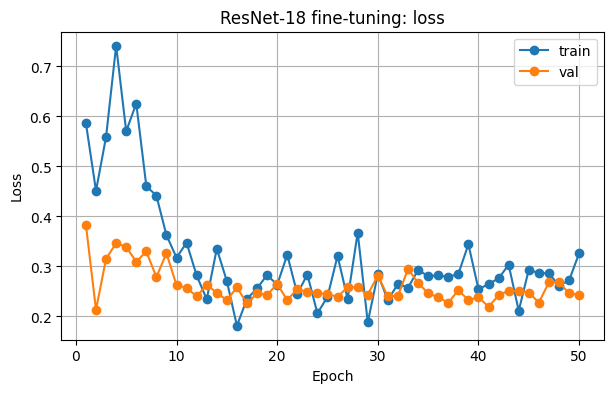

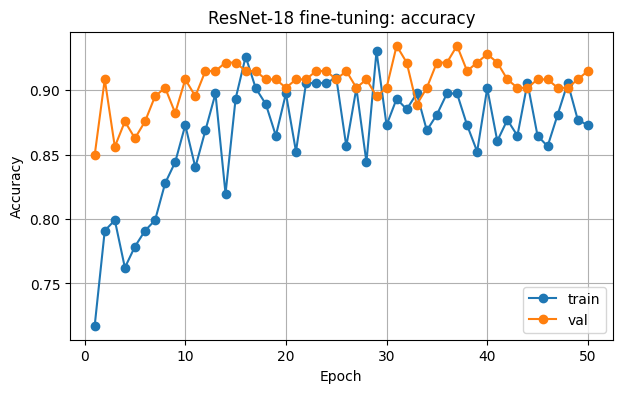

In [ ]:
NUM_EPOCHS = 50


model_ft, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=True)
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss() # 손실함수
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9) # 확률적 경사하강법 + 모멘텀(관성)
scheduler_ft = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1) # 학습률 스케줄러

print("Fine-tuning model parameter summary")
summarize_parameters(model_ft, max_rows=12)

model_ft, history_ft = fit_model(
    model=model_ft,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft,
    device=device,
    num_epochs=NUM_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / "resnet18_finetuning_best.pt",
    run_name="resnet18_finetuning",
)

plot_history(history_ft, title="ResNet-18 fine-tuning")

## 14. Fine-tuning 결과 시각화

아래 이미지는 PyTorch 공식 튜토리얼의 fine-tuning 모델 예측 결과 예시임. 실제 결과는 seed, augmentation, runtime, 라이브러리 버전에 따라 일부 달라질 수 있음.

![PyTorch transfer learning tutorial fine-tuning predictions](https://docs.pytorch.org/tutorials/_images/sphx_glr_transfer_learning_tutorial_002.png)

그림 2. fine-tuning 모델의 검증 이미지 예측 예시. 출처: PyTorch Tutorials, Transfer Learning for Computer Vision Tutorial.

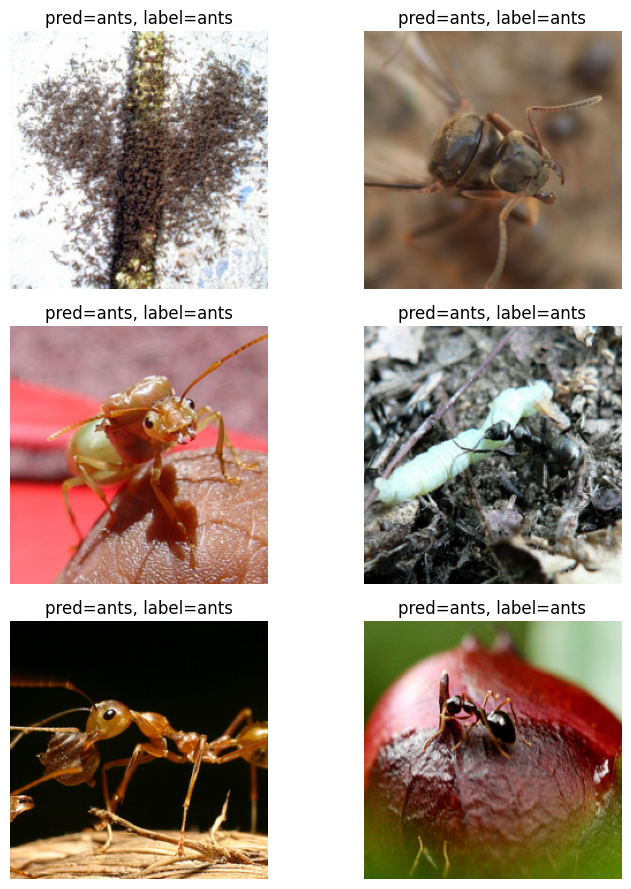

In [ ]:
def visualize_model_predictions(
    model: nn.Module,
    dataloader: DataLoader,
    class_names: List[str],
    num_images: int = 6,
) -> None:
    model.eval()
    images_so_far = 0
    rows = int(np.ceil(num_images / 2)) # 이미지 개수에 맞춰 세로 칸 수 계산
    cols = 2 # 가로는 2로 고정
    plt.figure(figsize=(8, 3 * rows))

    with torch.no_grad():
        for inputs_batch, labels_batch in dataloader:
            inputs_batch = inputs_batch.to(device, non_blocking=PIN_MEMORY)
            labels_batch = labels_batch.to(device, non_blocking=PIN_MEMORY)
            outputs = model(inputs_batch)
            preds = outputs.argmax(dim=1) # 가장 높은 점수를 받은 클래스 번호

            for j in range(inputs_batch.size(0)):
                images_so_far += 1
                ax = plt.subplot(rows, cols, images_so_far)
                ax.axis("off")
                predicted = class_names[preds[j].item()] # 모델의 예측
                actual = class_names[labels_batch[j].item()] # 실제 정답
                ax.set_title(f"pred={predicted}, label={actual}")
                image_to_show = denormalize(inputs_batch[j].detach().cpu()).clamp(0, 1)
                ax.imshow(image_to_show.numpy().transpose((1, 2, 0)))

                if images_so_far == num_images:
                    plt.tight_layout()
                    plt.show()
                    return

    plt.tight_layout()
    plt.show()


visualize_model_predictions(model_ft, dataloaders["val"], class_names, num_images=6)

## 15. 실험 2: 고정 feature extractor 방식

두 번째 실험은 원본 튜토리얼의 `ConvNet as fixed feature extractor` 단계에 해당함. 사전학습된 ResNet-18의 convolutional backbone parameter를 고정하고, 마지막 classifier만 학습함.

구현상 핵심은 backbone parameter에 대해 `param.requires_grad = False`를 설정하는 것임. 이후 새로 교체한 `model.fc`의 parameter는 기본적으로 `requires_grad=True`이므로 optimizer에는 `model.fc.parameters()`만 전달함. 이 설정에서 backward pass는 classifier weight와 bias에 대한 gradient만 계산하여 갱신함.

고정 feature extractor 방식은 학습할 parameter 수가 적어 작은 데이터셋에서 과적합 위험을 낮출 수 있음. 반면 target domain이 source domain과 크게 다르면 backbone을 갱신하지 못해 표현 적응력이 제한될 수 있음.

Fixed feature extractor parameter summary
Total parameters    : 11,177,538
Trainable parameters: 1,026
Frozen parameters   : 11,176,512

Parameter tensors
name                                          shape                         numel  trainable
-----------------------------------------------------------------------------------------------
conv1.weight                                  (64, 3, 7, 7)                 9,408      False
bn1.weight                                    (64,)                            64      False
bn1.bias                                      (64,)                            64      False
layer1.0.conv1.weight                         (64, 64, 3, 3)               36,864      False
layer1.0.bn1.weight                           (64,)                            64      False
layer1.0.bn1.bias                             (64,)                            64      False
layer1.0.conv2.weight                         (64, 64, 3, 3)               36,864      False
layer

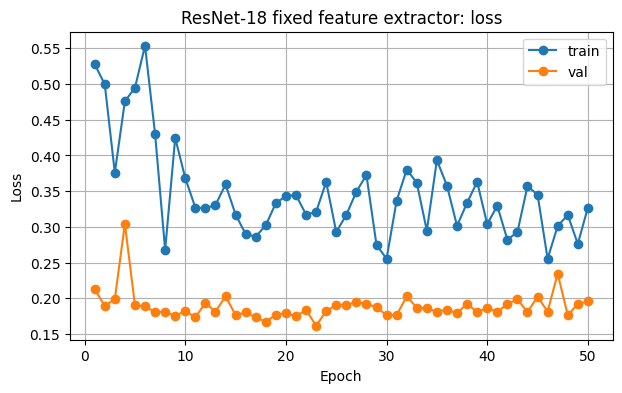

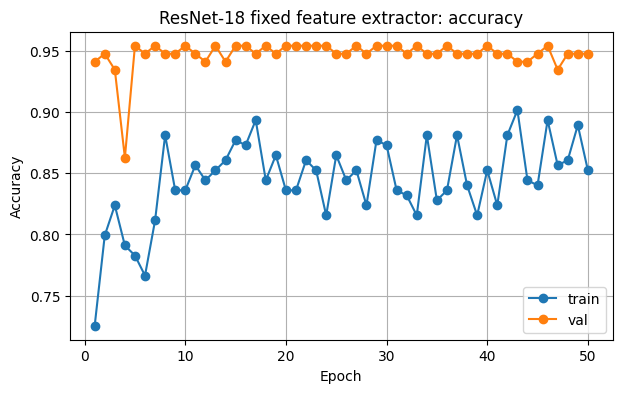

In [ ]:
model_conv, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=False)
model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)
scheduler_conv = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

print("Fixed feature extractor parameter summary")
summarize_parameters(model_conv, max_rows=12)

model_conv, history_conv = fit_model(
    model=model_conv,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer_conv,
    scheduler=scheduler_conv,
    device=device,
    num_epochs=NUM_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / "resnet18_fixed_feature_best.pt",
    run_name="resnet18_fixed_feature",
)

plot_history(history_conv, title="ResNet-18 fixed feature extractor")

## 16. Fixed feature extractor 결과 시각화

아래 이미지는 PyTorch 공식 튜토리얼의 fixed feature extractor 모델 예측 결과 예시임. 본 강의의 코드는 같은 데이터와 같은 학습 절차를 사용하되, 학습 함수와 metric 기록 구조를 분리하여 작성함.

![PyTorch transfer learning tutorial fixed feature predictions](https://docs.pytorch.org/tutorials/_images/sphx_glr_transfer_learning_tutorial_003.png)

그림 3. 고정 feature extractor 모델의 검증 이미지 예측 예시. 출처: PyTorch Tutorials, Transfer Learning for Computer Vision Tutorial.

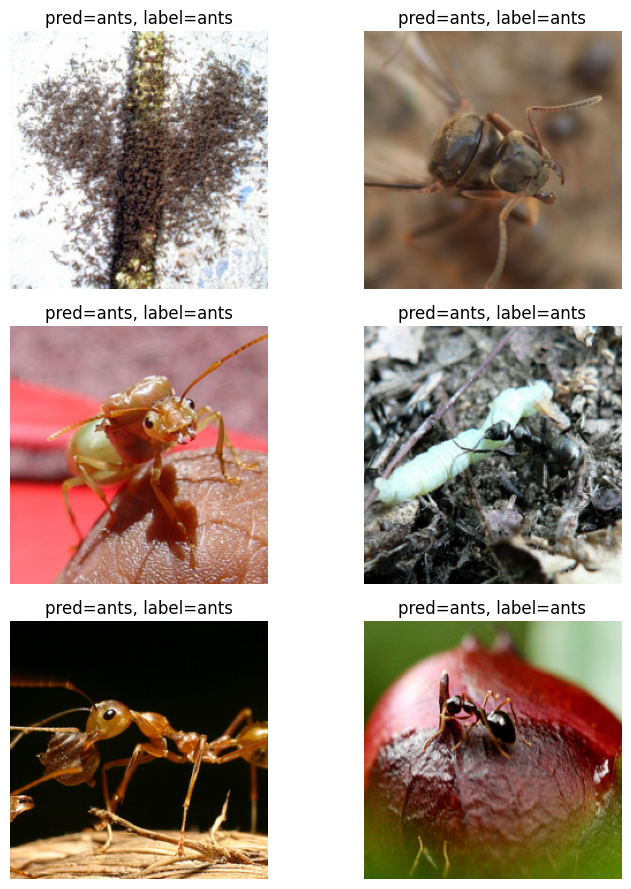

In [ ]:
visualize_model_predictions(model_conv, dataloaders["val"], class_names, num_images=6)

## 17. 두 전이학습 방식의 metric 비교

fine-tuning 방식은 더 많은 parameter를 갱신하므로 target 데이터에 더 적극적으로 적응할 수 있음. fixed feature extractor 방식은 classifier만 갱신하므로 계산량과 과적합 위험이 줄어드는 구조임. 어느 방식이 우수한지는 데이터 수, source-target domain 차이, augmentation 강도, optimizer 설정에 따라 달라짐.

아래 비교는 validation accuracy 기준의 간단한 요약임. 학습 시간이 중요한 경우에는 parameter 수와 epoch당 처리 시간도 함께 기록하는 것이 적절함.

In [ ]:
comparison_rows = [
    summarize_history(history_ft, "fine_tuning"),
    summarize_history(history_conv, "fixed_feature"),
]

print(f"{'name':18s} {'best_epoch':>10s} {'best_val_acc':>14s} {'final_train_acc':>16s} {'final_val_acc':>14s}")
print("-" * 78)
for row in comparison_rows:
    print(
        f"{row['name']:18s} "
        f"{row['best_epoch']:10.0f} "
        f"{row['best_val_acc']:14.4f} "
        f"{row['final_train_acc']:16.4f} "
        f"{row['final_val_acc']:14.4f}"
    )

name               best_epoch   best_val_acc  final_train_acc  final_val_acc
------------------------------------------------------------------------------
fine_tuning                31         0.9346           0.8730         0.9150
fixed_feature               5         0.9542           0.8525         0.9477


## 18. `state_dict` 기반 저장과 복원

PyTorch에서 model 저장은 전체 Python 객체를 직렬화하기보다 `state_dict`를 저장하는 방식이 일반적임. `state_dict`는 module의 학습 가능한 parameter와 buffer를 이름과 tensor 값의 mapping으로 보관함. 같은 architecture를 새로 생성한 뒤 `load_state_dict()`로 값을 주입하면 학습된 모델을 복원할 수 있음.

복원 검증은 같은 입력 batch에 대해 원본 모델과 복원 모델의 logit 차이가 거의 $0$인지 확인하는 방식으로 수행함. floating-point 연산과 device 차이에 따라 아주 작은 수치 차이는 가능함.

In [ ]:
STATE_DICT_PATH = CHECKPOINT_DIR / "resnet18_fixed_feature_state_dict.pt"
torch.save(model_conv.state_dict(), STATE_DICT_PATH)
print(f"Saved state_dict to: {STATE_DICT_PATH}")

restored_model, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=False)
restored_state_dict = safe_load_state_dict(STATE_DICT_PATH, map_location=device)
restored_model.load_state_dict(restored_state_dict)
restored_model = restored_model.to(device)
restored_model.eval()
model_conv.eval()

with torch.no_grad():
    sample_inputs = inputs.to(device, non_blocking=PIN_MEMORY)
    original_logits = model_conv(sample_inputs)
    restored_logits = restored_model(sample_inputs)
    max_abs_diff = (original_logits - restored_logits).abs().max().item()

print(f"Maximum absolute difference between logits: {max_abs_diff:.8f}")

Saved state_dict to: /content/checkpoints/resnet18_fixed_feature_state_dict.pt
Maximum absolute difference between logits: 0.00000000


## 19. 단일 이미지 추론

원본 튜토리얼은 학습된 모델로 단일 이미지를 예측하는 절차를 포함함. 학습·검증 batch에서는 `DataLoader`가 batch dimension을 자동으로 생성하지만, 단일 이미지를 직접 추론할 때는 `unsqueeze(0)`을 적용하여 shape를 $[1, 3, 224, 224]$로 만들어야 함.

추론에서 `softmax`는 class별 확률 해석을 위해 사용함. 학습 손실인 `CrossEntropyLoss`에는 softmax를 사전에 적용하지 않는다는 점과 구분해야 함.

{'image_path': '/content/data/hymenoptera_data/val/bees/2883093452_7e3a1eb53f.jpg', 'input_shape': (1, 3, 224, 224), 'predicted_label': 'bees', 'predicted_probability': 0.9995031356811523, 'logits': [-4.735885143280029, 2.870751142501831]}


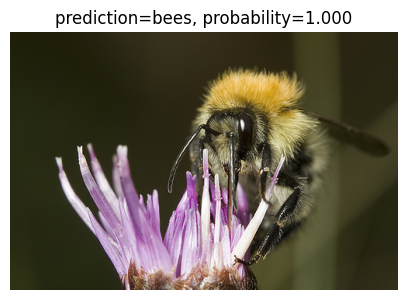

In [ ]:
@torch.no_grad()
def predict_image(
    model: nn.Module,
    image_path: Path,
    transform: transforms.Compose,
    class_names: List[str],
    device: torch.device,
) -> Dict[str, object]:
    model.eval()
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)
    logits = model(input_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predicted_index = int(probabilities.argmax(dim=1).item())
    return {
        "image_path": str(image_path),
        "input_shape": tuple(input_tensor.shape),
        "predicted_label": class_names[predicted_index],
        "predicted_probability": float(probabilities[0, predicted_index].item()),
        "logits": logits.detach().cpu().squeeze(0).tolist(),
    }


sample_image_path = next((DATA_DIR / "val" / "bees").glob("*.jpg"))
prediction = predict_image(restored_model, sample_image_path, data_transforms["val"], class_names, device)
print(prediction)

original_image = Image.open(sample_image_path).convert("RGB")
plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.title(f"prediction={prediction['predicted_label']}, probability={prediction['predicted_probability']:.3f}")
plt.axis("off")
plt.show()

## 20. 자주 발생하는 오류와 점검 기준

- `CrossEntropyLoss` 입력에 softmax를 미리 적용하면 손실 계산이 중복 정규화 구조가 되므로 부적절함. 입력은 raw logits이어야 함.
- target label은 one-hot이 아니라 shape $[B]$의 class index tensor이어야 하며 dtype은 `torch.long`이어야 함.
- model과 input tensor가 서로 다른 device에 있으면 연산 오류가 발생함. `model.to(device)`와 `inputs.to(device)`가 같은 device를 가리켜야 함.
- 정규화된 tensor를 그대로 시각화하면 색상이 왜곡됨. 표시 전에는 ImageNet 평균과 표준편차에 대한 역변환이 필요함.
- `model.eval()`은 dropout과 batch normalization 동작을 평가 mode로 바꾸지만, gradient 계산 자체를 끄지는 않음. 평가와 추론에서는 `torch.no_grad()` 또는 `torch.inference_mode()`를 함께 사용하는 것이 적절함.
- parameter를 freeze한 뒤에도 optimizer가 freeze parameter를 포함할 수 있음. 일반적으로 `filter(lambda p: p.requires_grad, model.parameters())` 또는 특정 layer parameter만 optimizer에 전달하는 구성이 명확함.

## 21. 확장 실험 1: 부분 fine-tuning

전체 backbone을 모두 갱신하는 방식과 classifier만 갱신하는 방식 사이의 중간 설정으로, `layer4`와 `fc`만 학습하는 부분 fine-tuning을 실험할 수 있음. 이 설정은 high-level semantic feature를 담당하는 마지막 residual stage만 target task에 적응시키는 구조임.

아래 함수는 새 ResNet-18 모델을 구성하고, parameter 이름이 `layer4` 또는 `fc`로 시작하는 경우에만 학습 가능하도록 설정함. 실행 시 동일한 `fit_model()` 학습 루프를 사용함.

In [ ]:
def build_resnet18_partial_finetune(
    num_classes: int,
    trainable_prefixes: Tuple[str, ...] = ("layer4", "fc"),
) -> nn.Module:
    model, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=True)
    for name, param in model.named_parameters():
        param.requires_grad = any(name.startswith(prefix) for prefix in trainable_prefixes)
    return model


def run_partial_finetuning_experiment(num_epochs: int = 10) -> Tuple[nn.Module, List[Dict[str, float]]]:
    model_partial = build_resnet18_partial_finetune(num_classes=num_classes)
    model_partial = model_partial.to(device)
    trainable_parameters = [param for param in model_partial.parameters() if param.requires_grad]
    optimizer_partial = optim.SGD(trainable_parameters, lr=0.001, momentum=0.9)
    scheduler_partial = lr_scheduler.StepLR(optimizer_partial, step_size=7, gamma=0.1)
    summarize_parameters(model_partial, max_rows=20)
    return fit_model(
        model=model_partial,
        dataloaders=dataloaders,
        criterion=nn.CrossEntropyLoss(),
        optimizer=optimizer_partial,
        scheduler=scheduler_partial,
        device=device,
        num_epochs=num_epochs,
        checkpoint_path=CHECKPOINT_DIR / "resnet18_partial_finetuning_best.pt",
        run_name="resnet18_partial_finetuning",
    )


print("Defined: run_partial_finetuning_experiment(num_epochs=10)")

Defined: run_partial_finetuning_experiment(num_epochs=10)


## 22. 확장 실험 2: label smoothing과 class probability calibration

작은 데이터셋에서 모델이 validation sample에 과도하게 확신하는 경향을 보일 수 있음. `nn.CrossEntropyLoss`의 `label_smoothing` 인자에 $\alpha$를 지정하면 hard target 분포를 완화하여 과도한 logit magnitude 증가를 줄이는 정규화 효과를 줄 수 있음.

class 수가 $C$이고 true class가 $y$인 경우, label smoothing은 target distribution을 다음 형태로 완화함.

$$
q_c =
\begin{cases}
1-\alpha + \alpha/C, & c=y \\
\alpha/C, & c \ne y
\end{cases}
$$

아래 함수는 fixed feature extractor 설정에서 label smoothing을 적용하는 실험임.

In [ ]:
def run_label_smoothing_experiment(
    num_epochs: int = 10,
    label_smoothing: float = 0.1,
) -> Tuple[nn.Module, List[Dict[str, float]]]:
    model_smooth, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=False)
    model_smooth = model_smooth.to(device)
    optimizer_smooth = optim.SGD(model_smooth.fc.parameters(), lr=0.001, momentum=0.9)
    scheduler_smooth = lr_scheduler.StepLR(optimizer_smooth, step_size=7, gamma=0.1)
    criterion_smooth = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    summarize_parameters(model_smooth, max_rows=12)
    return fit_model(
        model=model_smooth,
        dataloaders=dataloaders,
        criterion=criterion_smooth,
        optimizer=optimizer_smooth,
        scheduler=scheduler_smooth,
        device=device,
        num_epochs=num_epochs,
        checkpoint_path=CHECKPOINT_DIR / "resnet18_fixed_feature_label_smoothing_best.pt",
        run_name="resnet18_fixed_feature_label_smoothing",
    )


print("Defined: run_label_smoothing_experiment(num_epochs=10, label_smoothing=0.1)")

Defined: run_label_smoothing_experiment(num_epochs=10, label_smoothing=0.1)


## 23. 확장 실험 3: pretrained weights transform 사용 비교

`torchvision` weights enum은 해당 weights에 맞는 preprocessing transform을 제공함. 학습 split에서는 augmentation이 필요하므로 직접 정의한 random transform을 유지하는 것이 일반적임. 반면 validation 또는 inference에서는 `weights.transforms()`를 사용하여 weights가 요구하는 resize, crop, normalize 설정을 일관되게 적용할 수 있음.

아래 코드는 validation transform을 weights metadata 기반 transform으로 교체해 동일 모델을 평가하는 절차임. augmentation이 없는 결정적 평가 pipeline의 일관성을 확인하는 목적임.

In [ ]:
def evaluate_with_weights_transform(model: nn.Module, weights: models.ResNet18_Weights) -> PhaseMetrics:
    weights_val_transform = weights.transforms()
    val_dataset_with_weights_transform = datasets.ImageFolder(str(DATA_DIR / "val"), weights_val_transform)
    val_loader_with_weights_transform = DataLoader(
        val_dataset_with_weights_transform,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return evaluate(model, val_loader_with_weights_transform, nn.CrossEntropyLoss(), device)


weights_transform_metrics = evaluate_with_weights_transform(restored_model, resnet18_weights)
print(f"Validation loss with weights.transforms(): {weights_transform_metrics.loss:.4f}")
print(f"Validation accuracy with weights.transforms(): {weights_transform_metrics.acc:.4f}")

## 24. 전체 구성 요약

본 강의의 핵심 구성은 다음과 같음.

- 원본 PyTorch 전이학습 튜토리얼의 순서인 데이터 loading, augmentation 시각화, 학습 함수, fine-tuning, fixed feature extractor, 추론 흐름을 유지함
- 최신 `torchvision` weights enum API를 사용하여 ResNet-18 ImageNet-1K weights를 명시적으로 불러옴
- `ImageFolder`, `DataLoader`, `Tensor`, `Module`, `Parameter`, autograd, `CrossEntropyLoss`, SGD, `StepLR`, TensorBoard, `state_dict` 저장·복원을 shape와 계산 흐름 중심으로 설명함
- 학습 루프를 `train_one_epoch()`, `evaluate()`, `fit_model()`로 분리하여 train/eval mode, gradient 계산, checkpoint 저장을 명확히 구성함
- fine-tuning과 fixed feature extractor를 같은 metric 기록 구조에서 비교하도록 구성함
- 단일 이미지 추론에서 batch dimension 추가와 probability 해석을 명시함
- Colab 런타임 감지, `/content` 기반 경로 설정, API availability 확인, 더미 forward pass 기반 실행환경 점검을 포함함

## 25. 학습 목표

이 강의를 완료한 뒤 기대되는 학습 목표는 다음과 같음.

- $B \times C \times H \times W$ 이미지 tensor와 $[B, C_{\mathrm{cls}}]$ logit tensor의 dimension 의미를 설명할 수 있음
- `ImageFolder`와 `DataLoader`가 파일 시스템 구조를 mini-batch tensor로 바꾸는 절차를 설명할 수 있음
- pretrained CNN의 classifier head를 교체하고 class 수에 맞는 output dimension을 구성할 수 있음
- fine-tuning과 fixed feature extractor의 parameter 갱신 범위를 `requires_grad`와 optimizer 관점에서 구분할 수 있음
- autograd 기반 학습 loop에서 `zero_grad`, `backward`, `step`, `eval`, `no_grad`의 역할을 설명할 수 있음
- `state_dict`로 model weight를 저장하고 동일 architecture에 복원할 수 있음
- 학습·검증 metric을 기록하고 validation 기준 best checkpoint를 선택할 수 있음

## 26. 참고 자료

- PyTorch Tutorials, Transfer Learning for Computer Vision Tutorial: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
- PyTorch Tensor API: https://docs.pytorch.org/docs/stable/tensors.html
- PyTorch `torch.nn.Module`: https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html
- PyTorch `torch.nn.Parameter`: https://docs.pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html
- PyTorch Autograd: https://docs.pytorch.org/docs/stable/autograd.html
- PyTorch `CrossEntropyLoss`: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- PyTorch `torch.optim.SGD`: https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html
- PyTorch `StepLR`: https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html
- PyTorch Saving and Loading Models: https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html
- PyTorch TensorBoard utilities: https://docs.pytorch.org/docs/stable/tensorboard.html
- TorchVision Models and Pretrained Weights: https://docs.pytorch.org/vision/stable/models.html
- TorchVision ResNet-18 weights: https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html
- TorchVision `ImageFolder`: https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html
- TorchVision Transforms: https://docs.pytorch.org/vision/stable/transforms.html
- ImageNet Large Scale Visual Recognition Challenge: https://image-net.org/challenges/LSVRC/2012/
- He et al., Deep Residual Learning for Image Recognition: https://arxiv.org/abs/1512.03385
- CS231n Transfer Learning Notes: https://cs231n.github.io/transfer-learning/